In [68]:
import yfinance as yf
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import os
import scipy.stats as stats
import scipy.optimize as opt

In [69]:

if not os.path.exists("monthly_returns.csv"):

    # Tickers for asset classes
    tickers = {
        'US Equities (SPY)': 'GSPC',
        'US 10Yr Bonds (IEF)': 'TNX',
        'US REITs (IYR)': 'IYR',
        'Commodities (GSG)': 'SPGSCI'
    }

    # Download monthly adjusted close prices
    data = yf.download(list(tickers.values()), start='2000-01-01', interval='1mo')['Close']

    data.columns = tickers.values()

    # Calculate monthly returns
    monthly_returns = data.pct_change().fillna(0)

    # Show or save result
    display(monthly_returns.head())

    # Optional: Save to CSV
    monthly_returns.to_csv("monthly_returns.csv")
    
else:
    # Load the monthly returns from the CSV file
    monthly_returns = pd.read_csv("monthly_returns.csv", index_col=0, parse_dates=True)
    monthly_returns.index = pd.to_datetime(monthly_returns.index)
    
    display(monthly_returns.head())
    

[*********************100%***********************]  4 of 4 completed

4 Failed downloads:
['SPGSCI', 'IYR', 'GSPC', 'TNX']: YFRateLimitError('Too Many Requests. Rate limited. Try after a while.')


,GSPC,TNX,IYR,SPGSCI
Date,,,,


In [70]:
annualized_returns = (1 + monthly_returns).prod() ** (12 / len(monthly_returns)) - 1
annualized_volatility = monthly_returns.std() * np.sqrt(12)
annualized_covariance = monthly_returns.cov() * 12

display(annualized_returns)
display(annualized_volatility)
display(annualized_covariance)


ZeroDivisionError: division by zero

In [ ]:
def optimization(type, returns, covariance, sharpe_ratio_condition = False, sharpe_ratio = 1):

    w = np.array([0.25, 0.25, 0.25, 0.25])
    bounds = tuple((0, 1) for _ in range(len(w)))
    weights_constraint = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    constraints = [weights_constraint]
    
    if sharpe_ratio_condition:
        returns = np.sqrt(np.diag(covariance))*sharpe_ratio
    
    # Type 1: Maximize return subject to annualized volatility less than 10%
    if type == 'volatility':
        
        target_volatility = 0.1
        constraints.append({'type': 'ineq', 'fun': lambda x: target_volatility - np.sqrt(np.dot(x.T, np.dot(covariance, x)))})
        obj = lambda x: -np.dot(x, returns)
        result = opt.minimize( obj, w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_weights = result.x
        optimal_return = -result.fun
        optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance, optimal_weights)))
        optimal_sharpe_ratio = optimal_return / optimal_volatility
    
    # Type 2: Minimize volatility subject to annualized return more than 4%
    if type == 'return':
        
        target_return = 0.04
        constraints.append({'type': 'ineq', 'fun': lambda x: np.dot(x, returns) - target_return})
        obj = lambda x: np.sqrt(np.dot(x.T, np.dot(covariance, x)))
        result = opt.minimize( obj, w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_weights = result.x
        optimal_return = np.dot(optimal_weights, returns)    
        optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance, optimal_weights)))
        optimal_sharpe_ratio = optimal_return / optimal_volatility
    
    # Type 3: Maximize Sharpe Ratio
    if type == 'sharpe_ratio':
        
        obj = lambda x: -np.dot(x, returns) / np.sqrt(np.dot(x.T, np.dot(covariance, x)))
        result = opt.minimize( obj, w, method='SLSQP', bounds=bounds, constraints=constraints)
        
        optimal_weights = result.x
        optimal_return = np.dot(optimal_weights, returns)
        optimal_volatility = np.sqrt(np.dot(optimal_weights.T, np.dot(covariance, optimal_weights)))
        optimal_sharpe_ratio = -result.fun
            
    return optimal_weights, optimal_return, optimal_volatility, optimal_sharpe_ratio

In [ ]:
weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance)

display("Optimal Weights (Max Return, Volatility < 10%)")
display(weights)
display("Expected Annualized Return")
display(returns)
display("Expected Annualized Volatility")
display(volatility)
display("Expected Sharpe Ratio")
display(sharpe_ratio)

'Optimal Weights (Max Return, Volatility < 10%)'

array([1.14925442e-17, 3.69461401e-01, 1.37530206e-01, 4.93008393e-01])

'Expected Annualized Return'

0.05785571482587227

'Expected Annualized Volatility'

0.1000001675326385

'Expected Sharpe Ratio'

0.5785561789882908

In [ ]:
weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance, True, sharpe_ratio=1)

display("Optimal Weights (Max Return, Volatility < 10%)")
display(weights)

weights, returns, volatility, sharpe_ratio = optimization('volatility', annualized_returns, annualized_covariance, True, sharpe_ratio=2)

display("Optimal Weights (Max Return, Volatility < 10%)")
display(weights)

'Optimal Weights (Max Return, Volatility < 10%)'

array([0.34024617, 0.352405  , 0.26174984, 0.04559899])

'Optimal Weights (Max Return, Volatility < 10%)'

array([0.34023461, 0.35239435, 0.26173383, 0.04563721])

In [ ]:
weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance)

display("Optimal Weights (Min Volatility, Return > 4%)")
display(weights)
display("Expected Annualized Return")
display(returns)
display("Expected Annualized Volatility")
display(volatility)
display("Expected Sharpe Ratio")
display(sharpe_ratio)

'Optimal Weights (Min Volatility, Return > 4%)'

array([1.19980635e-02, 7.75753393e-01, 1.14925430e-17, 2.12248543e-01])

'Expected Annualized Return'

0.04000000000004315

'Expected Annualized Volatility'

0.057128953098698435

'Expected Sharpe Ratio'

0.7001703659952849

In [ ]:
weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance, True)

display("Optimal Weights (Min Volatility, Return > 4%)")
display(weights)

weights, returns, volatility, sharpe_ratio = optimization('return', annualized_returns, annualized_covariance, True, sharpe_ratio=2)

display("Optimal Weights (Min Volatility, Return > 4%)")
display(weights)

'Optimal Weights (Min Volatility, Return > 4%)'

array([1.20842339e-01, 7.95487694e-01, 1.56125113e-17, 8.36699667e-02])

'Optimal Weights (Min Volatility, Return > 4%)'

array([1.20842339e-01, 7.95487694e-01, 1.56125113e-17, 8.36699667e-02])

In [ ]:
weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance)

display("Optimal Weights (Max Sharpe Ratio)")
display(weights)
display("Expected Annualized Return")
display(returns)
display("Expected Annualized Volatility")
display(volatility)
display("Expected Sharpe Ratio")
display(sharpe_ratio)

'Optimal Weights (Max Sharpe Ratio)'

array([0.        , 0.72569004, 0.        , 0.27430996])

'Expected Annualized Return'

0.04318867733809291

'Expected Annualized Volatility'

0.06016223666715316

'Expected Sharpe Ratio'

0.7178702078021756

In [ ]:
weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance, True)

display("Optimal Weights (Max Sharpe Ratio)")
display(weights)

weights, returns, volatility, sharpe_ratio = optimization('sharpe_ratio', annualized_returns, annualized_covariance, True, sharpe_ratio=2)

display("Optimal Weights (Max Sharpe Ratio)")
display(weights)

'Optimal Weights (Max Sharpe Ratio)'

array([0.1833441 , 0.675281  , 0.02613325, 0.11524165])

'Optimal Weights (Max Sharpe Ratio)'

array([0.18326234, 0.67534517, 0.02603708, 0.11535542])

In [ ]:
def minimum_volatility_portfolio(returns):
    
    annualized_volatility = returns.std() * np.sqrt(12)
    annualized_covariance = returns.cov() * 12

    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = tuple((0, 1) for _ in range(len(returns.columns)))
    initial_weights = np.array([1 / len(returns.columns)] * len(returns.columns))

    result = opt.minimize(
        lambda x: np.sqrt(np.dot(x.T, np.dot(annualized_covariance, x))),
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    optimal_weights = result.x

    return optimal_weights


def maximum_diversification_portfolio(returns):
    
    annualized_volatility = returns.std() * np.sqrt(12)
    annualized_covariance = returns.cov() * 12

    constraints = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}
    bounds = tuple((0, 1) for _ in range(len(returns.columns)))
    initial_weights = np.array([1 / len(returns.columns)] * len(returns.columns))

    result = opt.minimize(
        lambda x: -np.log(np.dot(x, annualized_volatility)) + np.log(np.sqrt(np.dot(x.T, np.dot(annualized_covariance, x)))),
        initial_weights,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints
    )

    optimal_weights = result.x
    
    return optimal_weights


In [ ]:
backtest_period = 60  # months
returns = pd.DataFrame()

for i in range(len(monthly_returns)):
    if i < backtest_period:
        w1 = [0.25, 0.25, 0.25, 0.25]
        w2 = w1
        w3 = w1
    else:
        
        rolling_window = monthly_returns.iloc[i - backtest_period:i]
        
        w1 = [0.25, 0.25, 0.25, 0.25]
        w2 = maximum_diversification_portfolio(rolling_window)
        w3 = minimum_volatility_portfolio(rolling_window)
        w1 = np.array(w1)
        w2 = np.array(w2)
        w3 = np.array(w3)
        
    portfolio_returns_equal = np.dot(monthly_returns.iloc[i], w1)
    portfolio_returns_max_div = np.dot(monthly_returns.iloc[i], w2)
    portfolio_returns_min_vol = np.dot(monthly_returns.iloc[i], w3)
    
    
    new_row = pd.DataFrame([[portfolio_returns_equal, portfolio_returns_max_div, portfolio_returns_min_vol]],
                           columns=['Equal', 'Max Div', 'Min Vol'], index=[monthly_returns.index[i]])
    returns = pd.concat([returns, new_row])

returns.index = monthly_returns.index
returns.index = pd.to_datetime(returns.index)
    
    
display(returns.head())
display(returns.tail())

,Equal,Max Div,Min Vol
Date,,,
2000-01-01,0.000000,0.000000,0.000000
2000-02-01,-0.003807,-0.003807,-0.003807
2000-03-01,0.023533,0.023533,0.023533
2000-04-01,-0.008167,-0.008167,-0.008167
2000-05-01,-0.003931,-0.003931,-0.003931


,Equal,Max Div,Min Vol
Date,,,
2024-12-01,-0.028430,-0.012295,-0.017224
2025-01-01,0.026172,0.017943,0.016002
2025-02-01,0.008810,0.015011,0.018851
2025-03-01,-0.013931,0.009089,0.007046
2025-04-01,-0.054408,-0.017606,0.002571


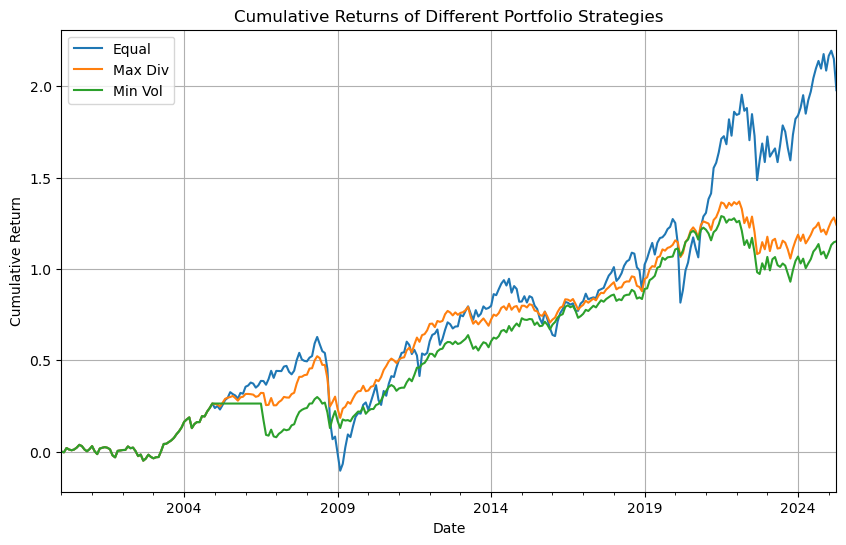

In [ ]:
cumulative_returns = (1 + returns).cumprod() - 1
cumulative_returns .plot(figsize=(10, 6))
plt.title('Cumulative Returns of Different Portfolio Strategies')
plt.xlabel('Date')
plt.ylabel('Cumulative Return')
plt.legend(loc='upper left')
plt.grid()
plt.show()

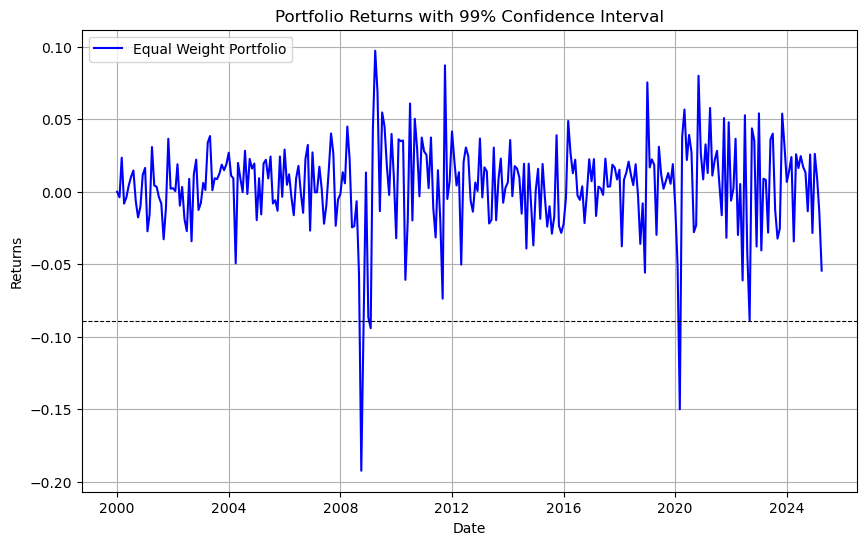

In [ ]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns['Equal'], label='Equal Weight Portfolio', color='blue')
plt.axhline(y= returns['Equal'].quantile(0.01), color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

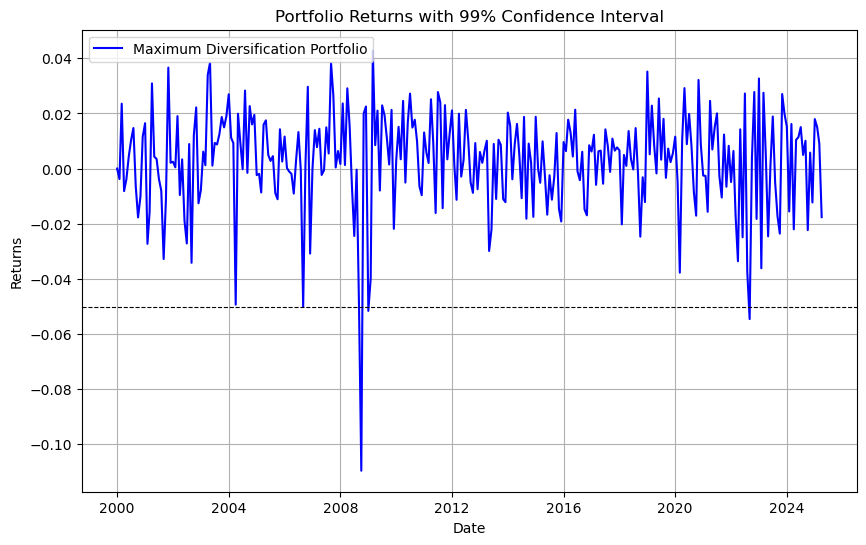

In [ ]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns['Max Div'], label='Maximum Diversification Portfolio', color='blue')
plt.axhline(y= returns['Max Div'].quantile(0.01) , color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()

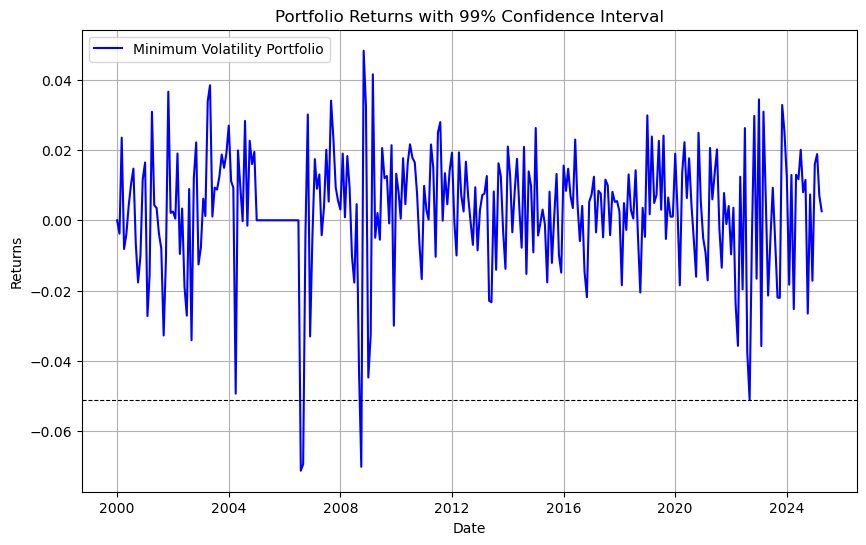

In [ ]:
# Plot the returns along with the 99% confidence interval
plt.figure(figsize=(10, 6))
plt.plot(returns['Min Vol'], label='Minimum Volatility Portfolio', color='blue')
plt.axhline(y= returns['Min Vol'].quantile(0.01), color='black', linestyle='--', linewidth=0.8)
plt.title('Portfolio Returns with 99% Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend(loc='upper left')
plt.grid()
plt.show()